# Output BAB 4.1.1 — Statistik Hasil Preprocessing

Notebook ini khusus membuat artefak untuk subbab **4.1.1 Statistik Hasil Preprocessing** sesuai `TODO_BAB_4_Lengkap.md` dan `TODO_BAB_4_Checklist_Output.md`. Output mencakup statistik VV/VH, HSV, Slope, HAND, validitas Sentinel-2, contoh visual channel, raw dB/clipping Sentinel-1, dan narasi interpretasi.

## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper untuk membaca raster/tile secara toleran.

In [1]:
from __future__ import annotations

import math
import re
from collections import defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

try:
    from matplotlib.colors import hsv_to_rgb
except Exception as exc:
    hsv_to_rgb = None
    HSV_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    HSV_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]
CHANNEL_FILES = {channel: f"{channel}.tif" for channel in CHANNEL_NAMES}

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_empty(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        print(f"failed reading {path.relative_to(ROOT)}: {type(exc).__name__}: {exc}")
        return pd.DataFrame()


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def quality_status(valid_pct: float, valid_pixels: int | float | None = None) -> str:
    if valid_pixels == 0 or valid_pct == 0:
        return "kosong"
    if valid_pct < 1:
        return "hampir kosong"
    if valid_pct < 25:
        return "rendah"
    return "baik"


def empty_stats(status: str, note: str = "") -> dict:
    return {
        "status": status,
        "note": note,
        "count": 0,
        "valid_pct": 0.0,
        "min": np.nan,
        "max": np.nan,
        "mean": np.nan,
        "std": np.nan,
        "p2": np.nan,
        "p98": np.nan,
        "height": np.nan,
        "width": np.nan,
        "crs": "",
        "transform": "",
    }


def finite_sample_percentiles(samples: list[np.ndarray]) -> tuple[float, float]:
    if not samples:
        return np.nan, np.nan
    values = np.concatenate(samples)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    return float(np.percentile(values, 2)), float(np.percentile(values, 98))


def raster_stats_blockwise(path: Path, mask_path: Path | None = None, sample_step: int = 20) -> dict:
    if rasterio is None:
        return empty_stats("skipped", f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}")
    if not path.exists():
        return empty_stats("missing", str(path.relative_to(ROOT)))
    try:
        with rasterio.open(path) as src:
            mask_src = rasterio.open(mask_path) if mask_path and mask_path.exists() else None
            total_pixels = src.height * src.width
            count = 0
            sum_val = 0.0
            sum_sq = 0.0
            min_val = math.inf
            max_val = -math.inf
            samples: list[np.ndarray] = []
            try:
                for _, window in src.block_windows(1):
                    arr = src.read(1, window=window, masked=True).astype("float64")
                    if np.ma.isMaskedArray(arr):
                        data = arr.filled(np.nan)
                    else:
                        data = np.asarray(arr)
                    valid = np.isfinite(data)
                    if mask_src is not None:
                        mask_arr = mask_src.read(1, window=window, masked=True)
                        if np.ma.isMaskedArray(mask_arr):
                            mask_data = mask_arr.filled(0)
                        else:
                            mask_data = np.asarray(mask_arr)
                        valid &= mask_data > 0
                    values = data[valid]
                    if values.size:
                        count += int(values.size)
                        sum_val += float(values.sum())
                        sum_sq += float(np.square(values).sum())
                        min_val = min(min_val, float(values.min()))
                        max_val = max(max_val, float(values.max()))
                        sampled = data[::sample_step, ::sample_step]
                        sampled_valid = valid[::sample_step, ::sample_step]
                        sampled_values = sampled[sampled_valid]
                        if sampled_values.size:
                            samples.append(sampled_values.astype("float32", copy=False))
            finally:
                if mask_src is not None:
                    mask_src.close()
            if count == 0:
                stats = empty_stats("ok", "no valid pixels after mask")
            else:
                mean = sum_val / count
                variance = max(0.0, sum_sq / count - mean * mean)
                p2, p98 = finite_sample_percentiles(samples)
                stats = {
                    "status": "ok",
                    "note": "",
                    "count": count,
                    "valid_pct": pct(count, total_pixels),
                    "min": min_val,
                    "max": max_val,
                    "mean": mean,
                    "std": math.sqrt(variance),
                    "p2": p2,
                    "p98": p98,
                    "height": src.height,
                    "width": src.width,
                    "crs": str(src.crs),
                    "transform": str(src.transform),
                }
            return stats
    except Exception as exc:
        return empty_stats("read_error", f"{type(exc).__name__}: {exc}")


def mask_counts(region: str) -> dict:
    feature_dir = DATASET / "features_preprocessed" / region
    s2_path = feature_dir / "s2_valid_mask.tif"
    feature_path = feature_dir / "feature_valid_mask.tif"
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not s2_path.exists():
        return {"status": "missing", "note": str(s2_path.relative_to(ROOT))}
    try:
        with rasterio.open(s2_path) as s2_src:
            feature_src = rasterio.open(feature_path) if feature_path.exists() else None
            total = s2_src.height * s2_src.width
            s2_valid = 0
            feature_valid = 0
            s2_within_feature = 0
            try:
                for _, window in s2_src.block_windows(1):
                    s2 = s2_src.read(1, window=window, masked=True)
                    s2_data = s2.filled(0) if np.ma.isMaskedArray(s2) else np.asarray(s2)
                    s2_mask = s2_data > 0
                    s2_valid += int(s2_mask.sum())
                    if feature_src is not None:
                        feature = feature_src.read(1, window=window, masked=True)
                        feature_data = feature.filled(0) if np.ma.isMaskedArray(feature) else np.asarray(feature)
                        feature_mask = feature_data > 0
                    else:
                        feature_mask = np.ones_like(s2_mask, dtype=bool)
                    feature_valid += int(feature_mask.sum())
                    s2_within_feature += int((s2_mask & feature_mask).sum())
            finally:
                if feature_src is not None:
                    feature_src.close()
            return {
                "status": "ok",
                "note": "",
                "raster_pixels": total,
                "s2_valid_pixels": s2_valid,
                "s2_valid_pct": pct(s2_valid, total),
                "feature_valid_pixels": feature_valid,
                "feature_valid_pct": pct(feature_valid, total),
                "s2_valid_pixels_within_feature_valid": s2_within_feature,
                "s2_valid_pct_within_feature_valid": pct(s2_within_feature, feature_valid),
                "height": s2_src.height,
                "width": s2_src.width,
                "crs": str(s2_src.crs),
            }
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def tile_masks(path: Path) -> tuple[np.lib.npyio.NpzFile, np.ndarray, np.ndarray, np.ndarray]:
    z = load_npz(path)
    x = np.asarray(z["x"])
    feature_valid = np.asarray(z.get("feature_valid_mask", z.get("valid_mask", np.ones((1, x.shape[-2], x.shape[-1])))))[0] > 0
    s2_valid = np.asarray(z.get("s2_valid_mask", np.zeros((1, x.shape[-2], x.shape[-1]))))[0] > 0
    return z, x, feature_valid, s2_valid


def tile_quality_metrics(path: Path) -> dict:
    _, x, feature_valid, s2_valid = tile_masks(path)
    valid_count = int(feature_valid.sum())
    if valid_count:
        vv_std = float(np.nanstd(x[0][feature_valid]))
        vh_std = float(np.nanstd(x[1][feature_valid]))
    else:
        vv_std = 0.0
        vh_std = 0.0
    return {
        "path": path,
        "region": path.parent.name,
        "tile": path.name,
        "feature_valid_ratio": float(feature_valid.mean()),
        "s2_valid_ratio": float((s2_valid & feature_valid).sum() / max(1, valid_count)),
        "s2_valid_raw_ratio": float(s2_valid.mean()),
        "vv_std_feature_valid": vv_std,
        "vh_std_feature_valid": vh_std,
        "sar_texture_score": vv_std + vh_std,
    }


def tile_s2_valid_ratio(path: Path) -> float:
    return tile_quality_metrics(path)["s2_valid_ratio"]


def choose_representative_s2_tile(regions: list[str], mode: str) -> dict | None:
    metrics = []
    for region in regions:
        files = sorted((DATASET / "tiles" / "7ch" / "by_region" / region).glob("*.npz"))
        for path in files:
            metrics.append(tile_quality_metrics(path))
    if not metrics:
        return None
    if mode == "valid":
        preferred = [m for m in metrics if m["s2_valid_ratio"] >= 0.95 and m["feature_valid_ratio"] >= 0.85]
        pool = preferred or metrics
        return sorted(pool, key=lambda m: (m["s2_valid_ratio"], m["feature_valid_ratio"], m["sar_texture_score"]), reverse=True)[0]
    preferred = [m for m in metrics if m["s2_valid_ratio"] <= 0.01 and m["feature_valid_ratio"] >= 0.85 and m["sar_texture_score"] > 0.05]
    pool = preferred or metrics
    return sorted(pool, key=lambda m: (m["feature_valid_ratio"], m["sar_texture_score"], -m["s2_valid_ratio"]), reverse=True)[0]


def choose_tile_by_s2(region: str, want: str) -> Path | None:
    choice = choose_representative_s2_tile([region], "valid" if want == "valid" else "empty")
    return choice["path"] if choice else None


def tile_hsv_rgb(x: np.ndarray) -> np.ndarray:
    hsv = np.stack([x[2], x[3], x[4]], axis=-1)
    if hsv_to_rgb is None:
        return np.clip(hsv, 0, 1)
    return np.clip(hsv_to_rgb(np.nan_to_num(hsv, nan=0.0)), 0, 1)


## 4.1.1 Statistik Preprocessing VV, VH, HSV, Slope, dan HAND

Membuat statistik per wilayah dari raster hasil preprocessing dengan `feature_valid_mask` sebagai batas area valid.

In [3]:
# rows = []
# for region in REGIONS:
#     feature_dir = DATASET / "features_preprocessed" / region
#     mask_path = feature_dir / "feature_valid_mask.tif"
#     for channel, filename in CHANNEL_FILES.items():
#         stats = raster_stats_blockwise(feature_dir / filename, mask_path=mask_path)
#         rows.append({
#             "region": region,
#             "channel": channel,
#             "source": str((feature_dir / filename).relative_to(ROOT)),
#             "mask_source": str(mask_path.relative_to(ROOT)) if mask_path.exists() else "",
#             **stats,
#         })

# preprocessing_stats = pd.DataFrame(rows)
# ordered_cols = [
#     "region", "channel", "source", "mask_source", "status", "note", "count", "valid_pct",
#     "min", "max", "mean", "std", "p2", "p98", "height", "width", "crs", "transform",
# ]
# preprocessing_stats = preprocessing_stats[[col for col in ordered_cols if col in preprocessing_stats.columns]]
# save_table(preprocessing_stats, "4_1_1_preprocessing_stats.csv")

# s1_stats = preprocessing_stats[preprocessing_stats["channel"].isin(["vv_norm", "vh_norm"])].copy()
# save_table(s1_stats, "4_1_1_sentinel1_vv_vh_stats.csv")

# hsv_stats = preprocessing_stats[preprocessing_stats["channel"].isin(["hue", "saturation", "value"])].copy()
# save_table(hsv_stats, "4_1_1_hsv_stats.csv")

# demnas_stats = preprocessing_stats[preprocessing_stats["channel"].isin(["slope_norm", "hand_norm"])].copy()
# save_table(demnas_stats, "4_1_1_demnas_slope_hand_stats.csv")


## 4.1.1 Validitas Sentinel-2 per Wilayah

Menghitung jumlah piksel valid `s2_valid_mask`, persentase valid, dan status kualitas optis (`baik`, `rendah`, `hampir kosong`, `kosong`).

saved table: outputs/bab4/tables/4_1_1_s2_valid_mask_by_region.csv (11 rows)


,region,status,note,raster_pixels,s2_valid_pixels,s2_valid_pct,feature_valid_pixels,feature_valid_pct,s2_valid_pixels_within_feature_valid,s2_valid_pct_within_feature_valid,height,width,crs,optical_data_quality,s2_valid_pct_feature_summary,feature_valid_pct_feature_summary
0,Aceh_Besar,ok,,78986850,22470061,28.4479,28366694,35.9132,22301991,78.6203,8175,9662,EPSG:32646,baik,28.447850,35.913186
1,Aceh_Tamiang,ok,,43550730,168,0.0004,21636316,49.6807,168,0.0008,7013,6210,EPSG:32647,hampir kosong,0.000386,49.680719
2,Aceh_Timur,ok,,102453120,29470457,28.7648,53531470,52.2497,29086768,54.3358,12096,8470,EPSG:32647,baik,28.764821,52.249722
3,Aceh_Utara,ok,,47180224,21505698,45.5820,26596884,56.3729,21117105,79.3969,5824,8101,EPSG:32647,baik,45.582018,56.372950
4,Agam,ok,,42694366,0,0.0000,22027974,51.5946,0,0.0000,4961,8606,EPSG:32747,kosong,0.000000,51.594569
5,Banda_Aceh,ok,,1233628,463066,37.5369,519063,42.0761,425578,81.9897,1058,1166,EPSG:32646,baik,37.536924,42.076136
6,Bireuen,ok,,28441575,15905307,55.9227,17831098,62.6938,15741744,88.2825,4275,6653,EPSG:32647,baik,55.922736,62.693778
7,Langsa,ok,,4156889,0,0.0000,2162309,52.0175,0,0.0000,1727,2407,EPSG:32647,kosong,0.000000,52.017482
8,Pasaman_Barat,ok,,81129415,1332,0.0016,38201429,47.0870,1332,0.0035,8117,9995,EPSG:32647,hampir kosong,0.001642,47.087026
9,Pidie,ok,,82428498,30348483,36.8179,31591717,38.3262,30098301,95.2728,9918,8311,EPSG:32647,baik,36.817950,38.326207


saved figure: outputs/bab4/figures/4_1_1_s2_valid_mask_by_region.png


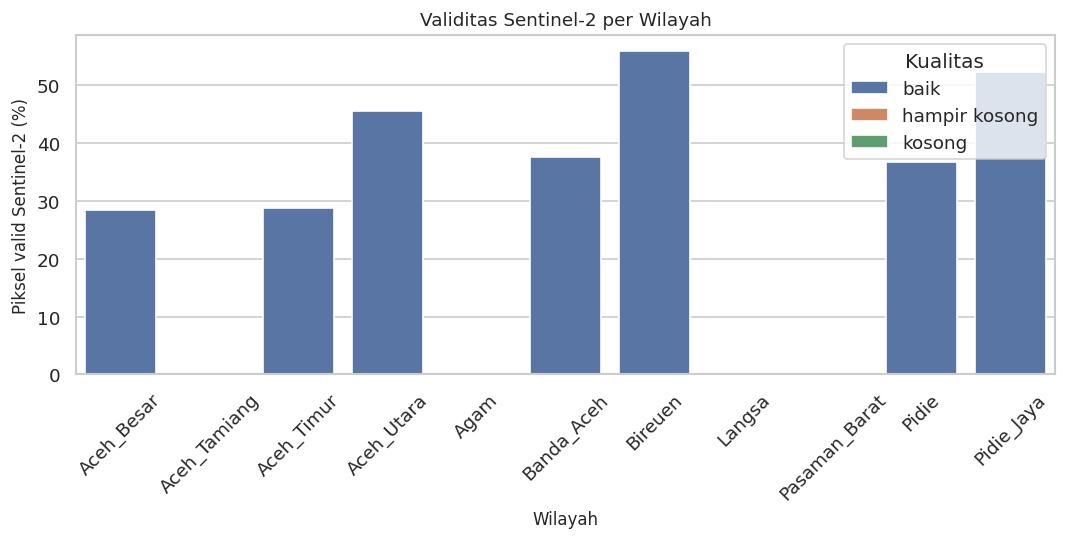

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_1_1_s2_valid_mask_by_region.png')

In [4]:
mask_rows = []
for region in REGIONS:
    counts = mask_counts(region)
    status_for_quality = counts.get("status")
    pct_for_quality = counts.get("s2_valid_pct", 0.0) if status_for_quality == "ok" else 0.0
    pixels_for_quality = counts.get("s2_valid_pixels", 0) if status_for_quality == "ok" else 0
    mask_rows.append({
        "region": region,
        **counts,
        "optical_data_quality": quality_status(pct_for_quality, pixels_for_quality) if status_for_quality == "ok" else "unknown",
    })

s2_table = pd.DataFrame(mask_rows).sort_values("region")
summary = read_csv_or_empty(DATASET / "feature_preprocessing_summary.csv")
if not summary.empty and "s2_valid_pct" in summary.columns:
    s2_table = s2_table.merge(
        summary[["region", "s2_valid_pct", "feature_valid_pct"]].rename(columns={
            "s2_valid_pct": "s2_valid_pct_feature_summary",
            "feature_valid_pct": "feature_valid_pct_feature_summary",
        }),
        on="region",
        how="left",
    )

save_table(s2_table, "4_1_1_s2_valid_mask_by_region.csv")

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_df = s2_table[s2_table["status"].eq("ok")].copy()
if not plot_df.empty:
    sns.barplot(data=plot_df, x="region", y="s2_valid_pct", hue="optical_data_quality", dodge=False, ax=ax)
    ax.set_ylabel("Piksel valid Sentinel-2 (%)")
    ax.set_xlabel("Wilayah")
    ax.tick_params(axis="x", rotation=45)
    ax.set_title("Validitas Sentinel-2 per Wilayah")
    ax.legend(title="Kualitas", loc="upper right")
else:
    ax.text(0.5, 0.5, "No S2 valid-mask data", ha="center", va="center")
    ax.axis("off")
save_fig(fig, "4_1_1_s2_valid_mask_by_region.png")


## 4.1.1 Visual Contoh Channel

Membuat panel contoh VV, VH, HSV, Slope, dan HAND pada wilayah representatif Aceh_Utara.

saved figure: outputs/bab4/figures/4_1_1_channel_example_aceh_utara.png


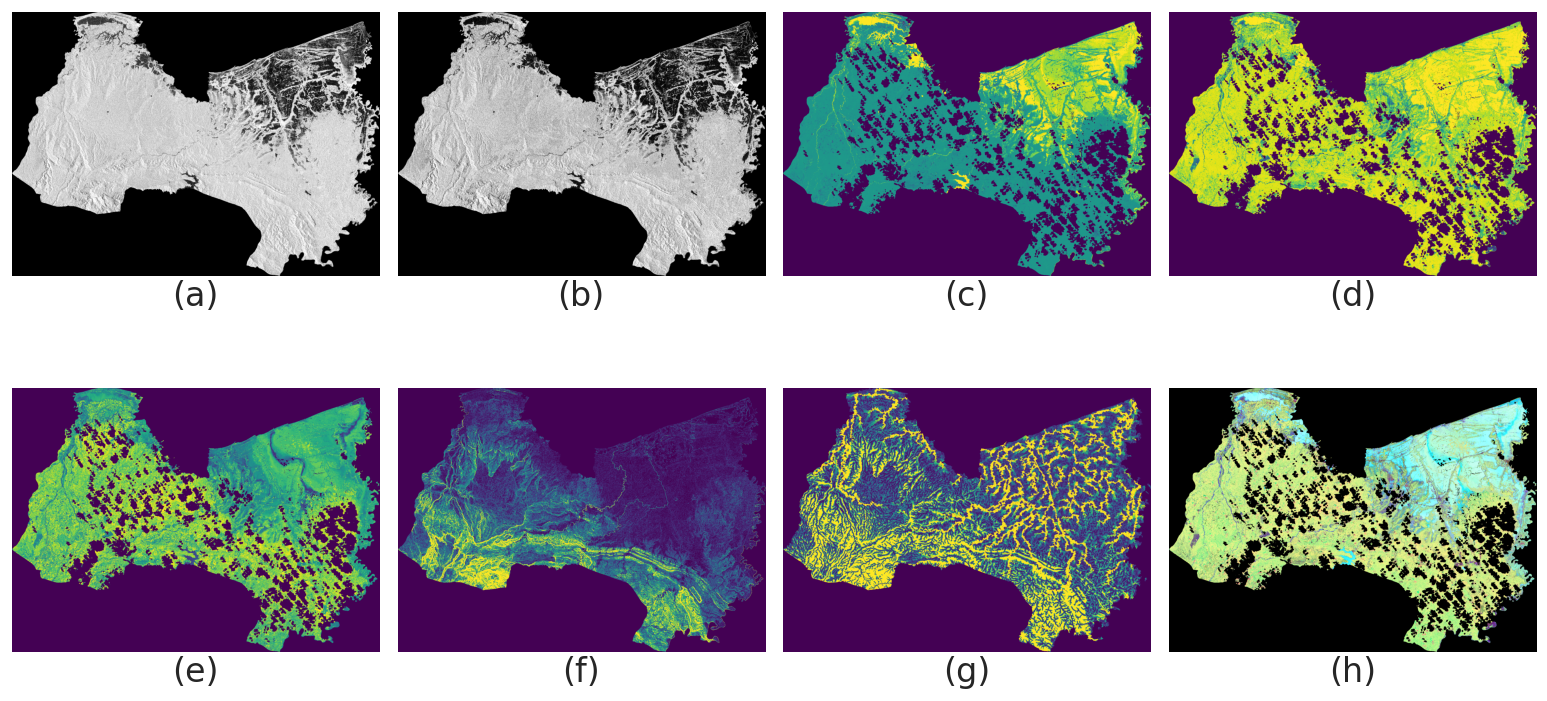

In [7]:
def read_region_channel_preview(region: str, channel: str, max_side: int = 1600) -> np.ndarray:
    feature_dir = DATASET / "features_preprocessed" / region
    raster_path = feature_dir / CHANNEL_FILES[channel]

    if rasterio is None:
        raise RuntimeError(f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}")

    if not raster_path.exists():
        raise FileNotFoundError(str(raster_path.relative_to(ROOT)))

    with rasterio.open(raster_path) as src:
        scale = min(1.0, max_side / max(src.width, src.height))
        out_w = max(1, int(round(src.width * scale)))
        out_h = max(1, int(round(src.height * scale)))
        arr = src.read(1, out_shape=(out_h, out_w), masked=True)

    return arr.filled(np.nan).astype("float32") if np.ma.isMaskedArray(arr) else np.asarray(arr, dtype="float32")


try:
    x_full = [read_region_channel_preview(TEST_REGION, channel) for channel in CHANNEL_NAMES]

except Exception as exc:
    status = pd.DataFrame([{
        "region": TEST_REGION,
        "status": "read_error",
        "note": f"{type(exc).__name__}: {exc}",
    }])
    save_table(status, "4_1_1_channel_example_status.csv")

else:
    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    axes = axes.ravel()

    subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]
    titles = ["VV", "VH", "Hue", "Saturation", "Value", "Slope", "HAND"]

    for idx, (channel, title) in enumerate(zip(CHANNEL_NAMES, titles)):
        cmap = "gray" if channel in {"vv_norm", "vh_norm"} else "viridis"

        axes[idx].imshow(normalize_image(x_full[idx]), cmap=cmap)

        # Label subplot di bawah gambar
        axes[idx].text(
            0.5, -0.015, subplot_labels[idx],
            transform=axes[idx].transAxes,
            ha="center", va="top",
            fontsize=20,
            clip_on=False
        )

        axes[idx].axis("off")

    pseudo_rgb = np.dstack([
        normalize_image(x_full[4]),
        normalize_image(x_full[3]),
        normalize_image(x_full[2])
    ])

    axes[7].imshow(pseudo_rgb)

    # Label subplot di bawah gambar
    axes[7].text(
        0.5, -0.015, subplot_labels[7],
        transform=axes[7].transAxes,
        ha="center", va="top",
        fontsize=20,
        clip_on=False
    )

    axes[7].axis("off")

    # Tidak memakai fig.suptitle
    fig.subplots_adjust(
        left=0.03,
        right=0.98,
        top=0.98,
        bottom=0.10,
        wspace=0.08,
        hspace=0.28
    )

    save_fig(fig, "4_1_1_channel_example_aceh_utara.png")

## 4.1.1 Perbandingan Sentinel-2 Valid dan Kosong/Hampir Kosong

Membuat contoh visual untuk wilayah dengan Sentinel-2 valid tertinggi dan terendah.

In [ ]:
valid_candidates = s2_table[s2_table["status"].eq("ok") & s2_table["s2_valid_pixels"].gt(0)]
empty_candidates = s2_table[
    s2_table["status"].eq("ok") &
    s2_table["optical_data_quality"].isin(["kosong", "hampir kosong", "rendah"])
]

if valid_candidates.empty or empty_candidates.empty:
    status = pd.DataFrame([{
        "status": "missing_candidate",
        "note": "Cannot choose S2 valid/empty comparison tiles"
    }])
    save_table(status, "4_1_1_s2_valid_vs_empty_status.csv")

else:
    valid_regions = valid_candidates.sort_values(
        ["s2_valid_pct", "s2_valid_pct_within_feature_valid"],
        ascending=False
    )["region"].tolist()

    empty_regions = empty_candidates.sort_values(
        ["s2_valid_pct", "feature_valid_pct"],
        ascending=[True, False]
    )["region"].tolist()

    valid_choice = choose_representative_s2_tile(valid_regions, "valid")
    empty_choice = choose_representative_s2_tile(empty_regions, "empty")

    comparison_specs = [
        ("S2 valid", valid_choice),
        ("S2 kosong/hampir kosong", empty_choice),
    ]

    selected_rows = []
    fig, axes = plt.subplots(2, 3, figsize=(12, 6.8))

    vv_cmap = plt.cm.gray.copy()
    vv_cmap.set_bad("#bdbdbd")

    subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

    for row_idx, (label, choice) in enumerate(comparison_specs):
        if choice is None:
            for col_idx, ax in enumerate(axes[row_idx]):
                panel_idx = row_idx * 3 + col_idx
                ax.text(0.5, 0.5, f"No tile for {label}", ha="center", va="center")
                ax.text(
                    0.5, -0.15, subplot_labels[panel_idx],
                    transform=ax.transAxes,
                    ha="center", va="top",
                    fontsize=30
                )
                ax.axis("off")
            continue

        tile_path = choice["path"]
        region = choice["region"]

        _, x, feature_valid, s2_valid = tile_masks(tile_path)

        ratio = choice["s2_valid_ratio"] * 100
        feature_ratio = choice["feature_valid_ratio"] * 100

        hsv_panel = tile_hsv_rgb(x)
        hsv_panel[~feature_valid] = np.array([0.74, 0.74, 0.74])

        s2_panel = np.zeros((*feature_valid.shape, 3), dtype="float32")
        s2_panel[s2_valid & feature_valid] = np.array([1.0, 1.0, 1.0])
        s2_panel[~feature_valid] = np.array([0.74, 0.74, 0.74])

        vv_panel = normalize_image(x[0])
        vv_panel = np.where(feature_valid, vv_panel, np.nan)

        panels = [
            (hsv_panel, None, None, None),
            (s2_panel, None, None, None),
            (vv_panel, vv_cmap, 0, 1),
        ]

        for col_idx, (image, cmap, vmin, vmax) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            panel_idx = row_idx * 3 + col_idx

            ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)

            # Label subplot di bawah gambar
            ax.text(
                0.5, -0.015, subplot_labels[panel_idx],
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=20
            )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
                spine.set_edgecolor("#444444")

        selected_rows.append({k: v for k, v in choice.items() if k != "path"})

    # Tidak memakai fig.suptitle
    fig.subplots_adjust(
        left=0.04,
        right=0.98,
        top=0.98,
        bottom=0.12,
        wspace=0.08,
        hspace=0.35
    )

    save_fig(fig, "4_1_1_s2_valid_vs_empty_comparison.png")
    save_table(
        pd.DataFrame(selected_rows),
        "4_1_1_s2_valid_vs_empty_tile_selection.csv"
    )

## 4.1.1 Raw dB, Clipping, dan Normalisasi

Melengkapi kebutuhan TODO tentang rentang raw Sentinel-1, clipping `[-30, 0]` dB, dan normalisasi `[0,1]`.

In [ ]:
def find_raw_s1(region: str) -> Path | None:
    raw_root = DATASET / "satelit raw"
    candidates = []
    variants = {region, region.replace("_", " ")}
    for folder in raw_root.glob("*"):
        folder_norm = folder.name.replace(" ", "_")
        if folder.name in variants or folder_norm == region:
            candidates.extend(sorted(folder.glob("S1_*.tif")))
    return candidates[0] if candidates else None


def sampled_band_stats(path: Path, band: int, max_size: int = 768) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    with rasterio.open(path) as src:
        out_h = min(src.height, max_size)
        out_w = min(src.width, max_size)
        arr = src.read(band, out_shape=(out_h, out_w), masked=True)
        vals = arr.compressed() if np.ma.isMaskedArray(arr) else arr.ravel()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            stats = {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
        else:
            stats = {
                "count": int(vals.size),
                "valid_pct": pct(vals.size, arr.size),
                "min": float(vals.min()),
                "max": float(vals.max()),
                "mean": float(vals.mean()),
                "std": float(vals.std()),
                "p2": float(np.percentile(vals, 2)),
                "p98": float(np.percentile(vals, 98)),
            }
        stats.update({
            "height": src.height,
            "width": src.width,
            "crs": str(src.crs),
            "band_description": src.descriptions[band-1] or f"band_{band}",
        })
        return stats

raw_rows = []
for region in REGIONS:
    raw = find_raw_s1(region)
    if raw is None:
        raw_rows.append({"region": region, "status": "missing_raw_s1", "source": "dataset/satelit raw"})
        continue
    with rasterio.open(raw) as src:
        band_map = {desc.upper() if desc else f"B{i}": i for i, desc in enumerate(src.descriptions, start=1)}
    for pol in ["VV", "VH"]:
        band = band_map.get(pol)
        if band is None:
            raw_rows.append({"region": region, "polarization": pol, "status": "missing_band", "source": str(raw.relative_to(ROOT))})
            continue
        stats = sampled_band_stats(raw, band)
        raw_rows.append({
            "region": region,
            "polarization": pol,
            "source": str(raw.relative_to(ROOT)),
            "clip_low_db": -30.0,
            "clip_high_db": 0.0,
            "normalization_formula": "clip(value, -30, 0); (value + 30) / 30",
            "status": "ok",
            **stats,
        })
raw_s1_stats = pd.DataFrame(raw_rows)
save_table(raw_s1_stats, "4_1_1_raw_s1_db_clipping_stats.csv")

policy = pd.DataFrame([
    {"feature": "Sentinel-1 VV/VH", "raw_unit": "dB", "clip_range": "[-30, 0]", "normalization": "(clip(value, -30, 0) + 30) / 30", "todo_coverage": "rentang nilai raw, clipping -30 dB sampai 0 dB, normalisasi [0,1]"},
    {"feature": "Sentinel-2 HSV", "raw_unit": "unitless", "clip_range": "[0, 1]", "normalization": "RGB/SWIR-NIR-Red clip lalu transformasi HSV", "todo_coverage": "pseudo-RGB/HSV dan validitas piksel setelah cloud masking"},
    {"feature": "Slope", "raw_unit": "degree", "clip_range": "[0, 45] atau konfigurasi preprocessing", "normalization": "normalize_clip", "todo_coverage": "fitur topografi untuk membatasi prediksi pada lereng curam"},
    {"feature": "HAND", "raw_unit": "meter", "clip_range": "[0, 50] atau konfigurasi preprocessing", "normalization": "normalize_clip", "todo_coverage": "ketinggian relatif terhadap drainase"},
])
save_table(policy, "4_1_1_preprocessing_policy_summary.csv")


## 4.1.1 Narasi Interpretasi

Menyimpan paragraf ringkas untuk menjelaskan karakter SAR, optis, topografi, wilayah S2 kosong/hampir kosong, dan alasan fusi multisensor.

In [ ]:
low_s2_regions = []
if "s2_table" in globals() and not s2_table.empty:
    low_s2_regions = s2_table[s2_table["optical_data_quality"].isin(["kosong", "hampir kosong", "rendah"])]["region"].tolist()
low_s2_text = ", ".join(low_s2_regions) if low_s2_regions else "tidak ada wilayah rendah/kosong yang terdeteksi"

interpretation_text = f"""# Interpretasi Karakter Input 4.1.1

Tahap preprocessing menghasilkan tujuh saluran fitur utama, yaitu VV, VH, Hue, Saturation, Value, Slope, dan HAND. Statistik pada tabel 4.1.1 menunjukkan bahwa seluruh saluran telah berada pada rentang ternormalisasi yang seragam sehingga siap digabungkan sebagai input tensor multisensor.

Sentinel-1 VV dan VH menjadi sumber utama yang tetap tersedia pada wilayah dengan tutupan awan atau Sentinel-2 tidak valid. Kanal VV/VH merekam respons hamburan radar sehingga membantu membedakan permukaan air, tanah basah, dan objek kasar, tetapi tetap dapat menghasilkan ambiguitas pada radar shadow atau badan air permanen.

Kanal optis HSV dari Sentinel-2 memberi konteks spektral dan visual ketika piksel valid tersedia. Wilayah dengan kualitas Sentinel-2 rendah/kosong pada tabel valid mask adalah {low_s2_text}. Pada wilayah tersebut, nilai HSV menjadi kurang informatif sehingga model harus lebih bergantung pada SAR dan topografi.

Slope dan HAND dari DEMNAS memberi konteks bentuk lahan. Slope membantu mengenali area curam yang berisiko menjadi sumber kesalahan radar, sedangkan HAND membantu membedakan area rendah dekat aliran air dari area yang secara topografis kurang mungkin tergenang.

Fusi multisensor diperlukan karena tidak ada satu sumber data yang selalu cukup. SAR kuat pada kondisi awan, optis memperkaya konteks saat valid, dan topografi membantu mengendalikan kesalahan spasial pada area sulit.
"""

narrative_path = NARRATIVE_DIR / "4_1_1_input_character_interpretation.md"
narrative_path.write_text(interpretation_text, encoding="utf-8")
print(f"saved narrative: {narrative_path.relative_to(ROOT)}")
print(interpretation_text)
narrative_path


## Checklist 4.1.1

Memverifikasi artefak 4.1.1 yang diminta TODO.

In [ ]:
expected = [
    ("wajib", "Statistik preprocessing VV, VH, HSV, Slope, HAND", TABLE_DIR / "4_1_1_preprocessing_stats.csv"),
    ("wajib", "Tabel statistik Sentinel-1 VV/VH", TABLE_DIR / "4_1_1_sentinel1_vv_vh_stats.csv"),
    ("wajib", "Tabel statistik Slope dan HAND", TABLE_DIR / "4_1_1_demnas_slope_hand_stats.csv"),
    ("wajib", "Tabel persentase valid Sentinel-2 per wilayah", TABLE_DIR / "4_1_1_s2_valid_mask_by_region.csv"),
    ("wajib", "Visual contoh channel VV, VH, HSV/pseudo-RGB, Slope, HAND", FIG_DIR / "4_1_1_channel_example_aceh_utara.png"),
    ("disarankan", "Visual perbandingan S2 valid vs kosong/hampir kosong", FIG_DIR / "4_1_1_s2_valid_vs_empty_comparison.png"),
    ("disarankan", "Statistik raw dB dan kebijakan clipping Sentinel-1", TABLE_DIR / "4_1_1_raw_s1_db_clipping_stats.csv"),
    ("disarankan", "Ringkasan kebijakan preprocessing", TABLE_DIR / "4_1_1_preprocessing_policy_summary.csv"),
    ("narasi_wajib", "Interpretasi karakter input dan alasan fusi multisensor", NARRATIVE_DIR / "4_1_1_input_character_interpretation.md"),
]
checklist = pd.DataFrame([
    {
        "priority": priority,
        "todo_item": todo_item,
        "artifact": str(path.relative_to(ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for priority, todo_item, path in expected
])
save_table(checklist, "4_1_1_todo_coverage_checklist.csv")
missing = checklist[~checklist["exists"]]
if missing.empty:
    print("All 4.1.1 TODO artifacts created.")
else:
    print("Missing 4.1.1 artifacts:")
    display(missing)
